In [1]:
import numpy as np
import pint

from jablonski import (
    SingletState,
    SpectroscopicSystem,
    initial,
    transitions,
)
from jablonski.plots.plots import graph_spectra
from jablonski.simulation import (
    emission_spectra,
    excitation_emission_matrix,
    excitation_spectra,
    widened_emission_spectra,
)
from jablonski.sweeps import (
    sweep_emission_spectra,
    sweep_spectral_steady_state_emission,
)

u = pint.get_application_registry()
E0 = -13.6 * u.eV


class Hydrogen(SpectroscopicSystem):
    n2: SingletState = initial(E0 / 2**2, "singlet", default=1)
    n3: SingletState = initial(E0 / 3**2, "singlet", default=0)
    n4: SingletState = initial(E0 / 4**2, "singlet", default=0)
    n5: SingletState = initial(E0 / 5**2, "singlet", default=0)
    n6: SingletState = initial(E0 / 6**2, "singlet", default=0)

    absorption_1 = transitions.Absorption(ground=n2, excited=n3, rate=1.7e-2 * u.cm**2)
    absorption_2 = transitions.Absorption(ground=n2, excited=n4, rate=3.6e-3 * u.cm**2)
    absorption_3 = transitions.Absorption(ground=n2, excited=n5, rate=1.18e-3 * u.cm**2)
    absorption_4 = transitions.Absorption(ground=n2, excited=n6, rate=5.81e-4 * u.cm**2)
    emission_1 = transitions.Fluorescence(ground=n2, excited=n3, rate=4.4e7 / u.s)
    emission_2 = transitions.Fluorescence(ground=n2, excited=n4, rate=8.4e6 / u.s)
    emission_3 = transitions.Fluorescence(ground=n2, excited=n5, rate=3.2e6 / u.s)
    emission_4 = transitions.Fluorescence(ground=n2, excited=n6, rate=1.5e7 / u.s)

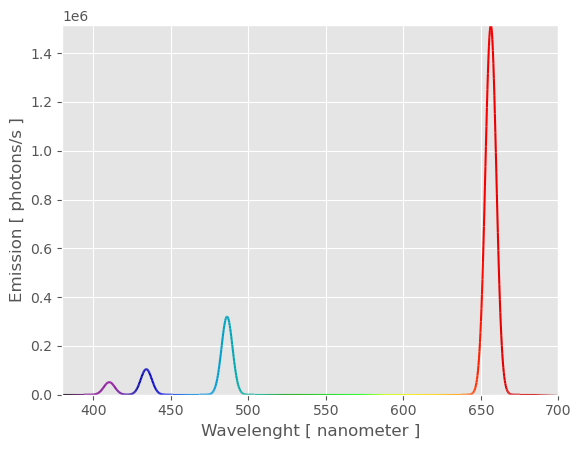

In [20]:
fig, ax = graph_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=1e8/(u.cm**2 *u.s),
)

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
fig.tight_layout()
fig.savefig(
    "../docs/images/jablonski_example.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.05,
)

In [3]:
import pint
ureg = pint.UnitRegistry()

# From a unit
base = ureg.get_base_units(ureg.kilometer)
# Returns: (multiplier, Unit) e.g. (1000.0, <Unit('meter')>)

# From a dimensionality string
base = ureg.get_base_units("[length]")

UndefinedUnitError: '[length]' is not defined in the unit registry